# GTSF Quant Mentorship TSF Project

## Part 1: Data Collection and Cleaning

### Data Collection

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
tickers = ["AAPL", "MSFT", "GOOGL", "NVDA"]
tsf_data = yf.download(tickers, start = "2007-01-01", end = "2025-12-31")
tsf_data.head()

[*********************100%***********************]  4 of 4 completed


Price          Close                                      High             \
Ticker          AAPL      GOOGL       MSFT      NVDA      AAPL      GOOGL   
Date                                                                        
2007-01-03  2.510899  11.605532  21.073963  0.551293  2.594197  11.830648   
2007-01-04  2.566631  11.994459  21.038675  0.548696  2.575320  12.011585   
2007-01-05  2.548353  12.092002  20.918697  0.514316  2.582810  12.099696   
2007-01-08  2.560938  12.002402  21.123373  0.518137  2.592699  12.158520   
2007-01-09  2.773675  12.050056  21.144547  0.508052  2.785960  12.118310   

Price                                 Low                                  \
Ticker           MSFT      NVDA      AAPL      GOOGL       MSFT      NVDA   
Date                                                                        
2007-01-03  21.349209  0.573296  2.453970  11.444699  20.749313  0.531582   
2007-01-04  21.151597  0.551293  2.511498  11.624395  20.777545  0.535249   
2007-01-05  20.996331  0.537847  2.528878  11.866637  20.784604  0.510649   
2007-01-08  21.243352  0.528068  2.555245  11.968151  20.841070  0.507287   
2007-01-09  21.299814  0.522414  2.551349  11.943331  20.982222  0.507440   

Price           Open                                      Volume             \
Ticker          AAPL      GOOGL       MSFT      NVDA        AAPL      GOOGL   
Date                                                                          
2007-01-03  2.585507  11.566069  21.109251  0.566420  1238319600  307951740   
2007-01-04  2.518391  11.640528  20.961043  0.549307   847260400  315188496   
2007-01-05  2.569926  11.975597  20.911640  0.535708   834741600  274609116   
2007-01-08  2.575620  12.104412  20.925760  0.516150   797106800  189985824   
2007-01-09  2.590302  12.048815  21.172778  0.518900  3349298400  215040744   

Price                             
Ticker          MSFT        NVDA  
Date                              
2007-01-03  76935100  1154820000  
2007-01-04  45774500   797298000  
2007-01-05  44607200  1243344000  
2007-01-08  50220200   657270000  
2007-01-09  44636600   764166000

### Data Cleaning and EDA

In [3]:
tsf_data.isna().sum()

Price   Ticker
Close   AAPL      0
        GOOGL     0
        MSFT      0
        NVDA      0
High    AAPL      0
        GOOGL     0
        MSFT      0
        NVDA      0
Low     AAPL      0
        GOOGL     0
        MSFT      0
        NVDA      0
Open    AAPL      0
        GOOGL     0
        MSFT      0
        NVDA      0
Volume  AAPL      0
        GOOGL     0
        MSFT      0
        NVDA      0
dtype: int64

***from here, we see that this dataset has no null values to handle***

In [4]:
tsf_data.dtypes

Price   Ticker
Close   AAPL      float64
        GOOGL     float64
        MSFT      float64
        NVDA      float64
High    AAPL      float64
        GOOGL     float64
        MSFT      float64
        NVDA      float64
Low     AAPL      float64
        GOOGL     float64
        MSFT      float64
        NVDA      float64
Open    AAPL      float64
        GOOGL     float64
        MSFT      float64
        NVDA      float64
Volume  AAPL        int64
        GOOGL       int64
        MSFT        int64
        NVDA        int64
dtype: object

***we also can observe that our dataset is consistent and all columns already have numeric datatypes***

In [5]:
tsf_data.index.duplicated().sum()

np.int64(0)

***we have no duplicated dates within the dataframe***

In [6]:
date_gaps = tsf_data.index.to_series().diff().dt.days

In [7]:
date_gaps = tsf_data.index.to_series().diff().dt.days
date_gaps[date_gaps > 5]  # anything over a weekend is suspicious


Series([], Name: Date, dtype: float64)

In [8]:
print(f"Start: {tsf_data.index.min()}, End: {tsf_data.index.max()}")
print(f"Total trading days: {len(tsf_data)}")

# 4. Check for zero volume days (can indicate data issues)
print((tsf_data['Volume'] == 0).sum())

Start: 2007-01-03 00:00:00, End: 2025-12-30 00:00:00
Total trading days: 4779
Ticker
AAPL     0
GOOGL    0
MSFT     0
NVDA     0
dtype: int64


In [9]:
# 5. Check for outliers in returns
returns = tsf_data['Close'].pct_change()
outliers = returns.stack()
print(outliers[outliers.abs() > 0.10])

Date        Ticker
2007-11-13  AAPL      0.105359
2008-01-07  NVDA     -0.103333
2008-01-16  NVDA     -0.112981
2008-01-23  AAPL     -0.106464
2008-02-14  NVDA     -0.163212
                        ...   
2024-07-31  NVDA      0.128121
2025-01-27  NVDA     -0.169682
2025-04-09  AAPL      0.153288
            MSFT      0.101337
            NVDA      0.187227
Length: 76, dtype: float64


***this series marks some important days where the change of the close price changed by 15% or more from 2007-2025***

In [10]:
# lets use these outliers to flag the data
log_returns = np.log(tsf_data['Close']/tsf_data['Close'].shift(1))

outlier_flags = log_returns.abs() > 0.10
outlier_flags.columns = pd.MultiIndex.from_tuples([('Outlier', col) for col in outlier_flags.columns])

In [11]:
#lets combine the dataframes now to actually show the flags
tsf_data = pd.concat([tsf_data, outlier_flags], axis =1)

In [12]:
tsf_data.head()

Close                                      High             \
                AAPL      GOOGL       MSFT      NVDA      AAPL      GOOGL   
Date                                                                        
2007-01-03  2.510899  11.605532  21.073963  0.551293  2.594197  11.830648   
2007-01-04  2.566631  11.994459  21.038675  0.548696  2.575320  12.011585   
2007-01-05  2.548353  12.092002  20.918697  0.514316  2.582810  12.099696   
2007-01-08  2.560938  12.002402  21.123373  0.518137  2.592699  12.158520   
2007-01-09  2.773675  12.050056  21.144547  0.508052  2.785960  12.118310   

                                      Low             ...       Open  \
                 MSFT      NVDA      AAPL      GOOGL  ...       MSFT   
Date                                                  ...              
2007-01-03  21.349209  0.573296  2.453970  11.444699  ...  21.109251   
2007-01-04  21.151597  0.551293  2.511498  11.624395  ...  20.961043   
2007-01-05  20.996331  0.537847  2.528878  11.866637  ...  20.911640   
2007-01-08  21.243352  0.528068  2.555245  11.968151  ...  20.925760   
2007-01-09  21.299814  0.522414  2.551349  11.943331  ...  21.172778   

                          Volume                                  Outlier  \
                NVDA        AAPL      GOOGL      MSFT        NVDA    AAPL   
Date                                                                        
2007-01-03  0.566420  1238319600  307951740  76935100  1154820000   False   
2007-01-04  0.549307   847260400  315188496  45774500   797298000   False   
2007-01-05  0.535708   834741600  274609116  44607200  1243344000   False   
2007-01-08  0.516150   797106800  189985824  50220200   657270000   False   
2007-01-09  0.518900  3349298400  215040744  44636600   764166000   False   

                                 
            GOOGL   MSFT   NVDA  
Date                             
2007-01-03  False  False  False  
2007-01-04  False  False  False  
2007-01-05  False  False  False  
2007-01-08  False  False  False  
2007-01-09  False  False  False  

[5 rows x 24 columns]

#### Let's create a visualization
* This visualization will graph the number of outliers per year to see how some years had more outliers due to big economic factors
* We'll use matplotlib for this task and use a bar graph
* The threshold to being an outlier is a 10% increase/decrease of close price from the log return

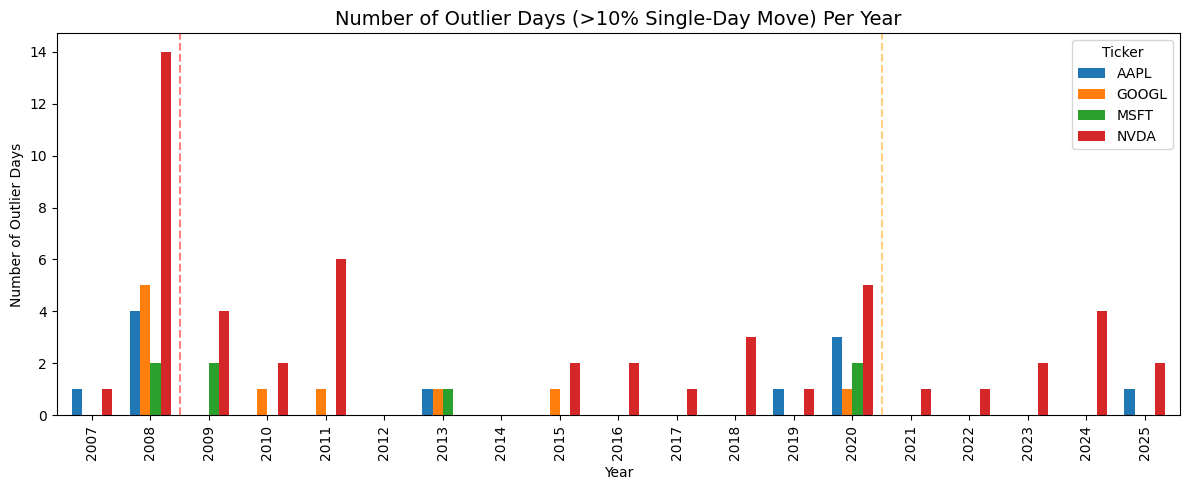

,AAPL,GOOGL,MSFT,NVDA,Count
Date,,,,,
2008,4,5,2,14,25
2020,3,1,2,5,11
2011,0,1,0,6,7
2009,0,0,2,4,6
2024,0,0,0,4,4
2018,0,0,0,3,3
2010,0,1,0,2,3
2013,1,1,1,0,3
2025,1,0,0,2,3


In [21]:
outlier_counts = tsf_data['Outlier'].copy()
outlier_counts.index = tsf_data.index.year # we want to count the outliers per year
yearly_outliers = outlier_counts.groupby(level = 0).sum() #grouping by the year

#lets make the actual plot now that we have our yearly_outliers
fig, ax = plt.subplots(figsize = (12,5))
yearly_outliers.plot(kind = 'bar', ax = ax, width = 0.7)

ax.set_title('Number of Outlier Days (>10% Single-Day Move) Per Year', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Outlier Days')
ax.legend(title='Ticker')
ax.axvline(x=1.5, color='red', linestyle='--', alpha=0.5, label='2008 Crisis')
ax.axvline(x=13.5, color='orange', linestyle='--', alpha=0.5, label='COVID')
plt.tight_layout()
plt.show()

#lets also show the rankings for which years had the most outliers within the dataset
year_out_c = yearly_outliers.copy()
year_out_c["Count"] = yearly_outliers.sum(axis = 1)
ranked_yearly_outliers = year_out_c.sort_values(by = 'Count', ascending = False)
display(ranked_yearly_outliers)

***Key Takeaways***
1. 2008 and 2020 recorded the most outliers within the dataframe. This makes sense because of the 2008 financial crisis
   and the COVID-19 epidemic that took place in 2020
2. 2012 and 2014 both recorded 0 outliers, showing that in both years, stock prices for these companies had low volatility
3. NVDA accounts for a majority of the outliers within the dataframe across all the years, reflecting that it had much higher volatility
   compared to AAPL, GOOGL, and MSFT, which behaved relatively stably even during the crisis periods, compared to NVDA
4. The re-emergence of NVDA outliers in 2023–2025 (2 in 2023, 4 in 2024, 2 in 2025) coincides with the AI boom, suggesting a new
   volatility regime driven by earnings surprises and rapid sentiment shifts around AI demand.
5. NVDA's outliers appear consistently from 2007 through 2025, while the other three stocks' outliers are almost entirely concentrated in
   2008 and 2020, suggesting NVDA's volatility is stock-specific rather than purely macro-driven.